In [ ]:
# >>> repo path setup (auto-added during reorg; keeps this notebook runnable from notebooks/) <<<
import os, sys
_p = os.getcwd()
while not os.path.isdir(os.path.join(_p, 'src')) and os.path.dirname(_p) != _p:
    _p = os.path.dirname(_p)
os.chdir(_p)
sys.path.insert(0, os.path.join(_p, 'src'))
# <<< end repo path setup >>>

In [26]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
import torch
import torch.nn.functional as F
import arviz as az
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

# SEISFWI imports
from utils.vae import VanillaVAE
from utils.project_plots import configure_plot_settings
from utils.project_utils import rockphysic_inversion
from utils import RockPhysicsModel
from seisfwi.model import AcousticModel, RockPhysicsGassmann
import seisfwi.defaults as defaults

from FWI_REG import get_survey

In [28]:
configure_plot_settings()

### Trained VAE Models

In [29]:
# Load VAE Model
kld_weight = 0.000015
in_channels = 1
latent_dim = 64
device = torch.device(defaults.device)
checkpoint_path = f"/net/vision/scr2/haipeng/FWI-HMC/VAE/vae_latent_dim{latent_dim}_kld_weight{kld_weight}.pth"

# Reload the model
model_vae = VanillaVAE(in_channels=in_channels, latent_dim=latent_dim).to(defaults.device)
model_vae.load_state_dict(torch.load(checkpoint_path, map_location=defaults.device))
model_vae.eval()

def decode_in_batches(model, latent_tensor, batch_size):
    """Decode latent vectors in batches to avoid GPU OOM."""
    decoded = []
    n_samples = latent_tensor.shape[0]

    with torch.no_grad():
        for i in tqdm(range(0, n_samples, batch_size), desc="Decoding batches"):
            batch = latent_tensor[i:i + batch_size]
            decoded_batch = model.decode(batch)
            decoded_batch = F.interpolate(decoded_batch, size=(15, 179), mode='bilinear', align_corners=False)
            decoded.append(decoded_batch.cpu())
            
    decoded = torch.cat(decoded, dim=0)
    # compute mean, std, p10, p50, p90
    p10 = torch.quantile(decoded, 0.1, dim=0).numpy().squeeze()
    p50 = torch.quantile(decoded, 0.5, dim=0).numpy().squeeze()
    p90 = torch.quantile(decoded, 0.9, dim=0).numpy().squeeze()
    mean = torch.mean(decoded, dim=0).numpy().squeeze()
    std = torch.std(decoded, dim=0).numpy().squeeze()
    
    decoded = decoded.numpy().squeeze()

    return decoded, mean, std, p10, p50, p90

In [30]:
nz0 = 260
nx0 = 110
nz_res = 15
nx_res = 179
x_res = (np.arange(nx_res) + nx0) * 5.0
z_res = (np.arange(nz_res) + nz0) * 5.0 
extent_res=[x_res[0]/1000, x_res[-1]/1000, z_res[-1]-z_res[0], 0]

### Rock physics inversion

In [31]:
vp_res = np.load("./model/vp_res_nz15_nx179_5m.npy")

# Parameters for rock physics model
rock_physics_params = RockPhysicsModel(vp_res)

# Gassmann fluid substitution
rockphy = RockPhysicsGassmann(**rock_physics_params)

    Brine properties: K = 2.62 GPa, rho = 1013.5368 kg/m3
      CO2 properties: K = 0.03 GPa, rho = 537.8947 kg/m3
  Mineral properties: K = 36.93 GPa, rho = 2645.1000 kg/m3
  Estimated porosity: phi = 0.1412


In [32]:
src_loc = {2: 570, 3: 1000, 4: 1420}
rec_loc = {1: [700], 2: [700, 1300]}

In [33]:
fontsize = 14
labels = ["a)", "b)", "c)", "d)"]

In [34]:
rec_id = 1
f0 = 30
noise_flag = "-noise-25dB"

# HMC parameters
num_samples = 40000
hmc_temp = 0.025

In [35]:
sa_obs = np.load('model/sa_res_nz15_nx179_5m.npy')
model_bl, model_ml, survey = get_survey(f0 = f0, src_id=1, rec_id=rec_id, vp_ml_file = f'model/vp_ml_nz346_nx401_5m.npy')

vp_bl = model_bl.get_model('vp')    
vp_ml = model_ml.get_model('vp')

Decoding batches: 100%|██████████| 79/79 [00:01<00:00, 48.96it/s]


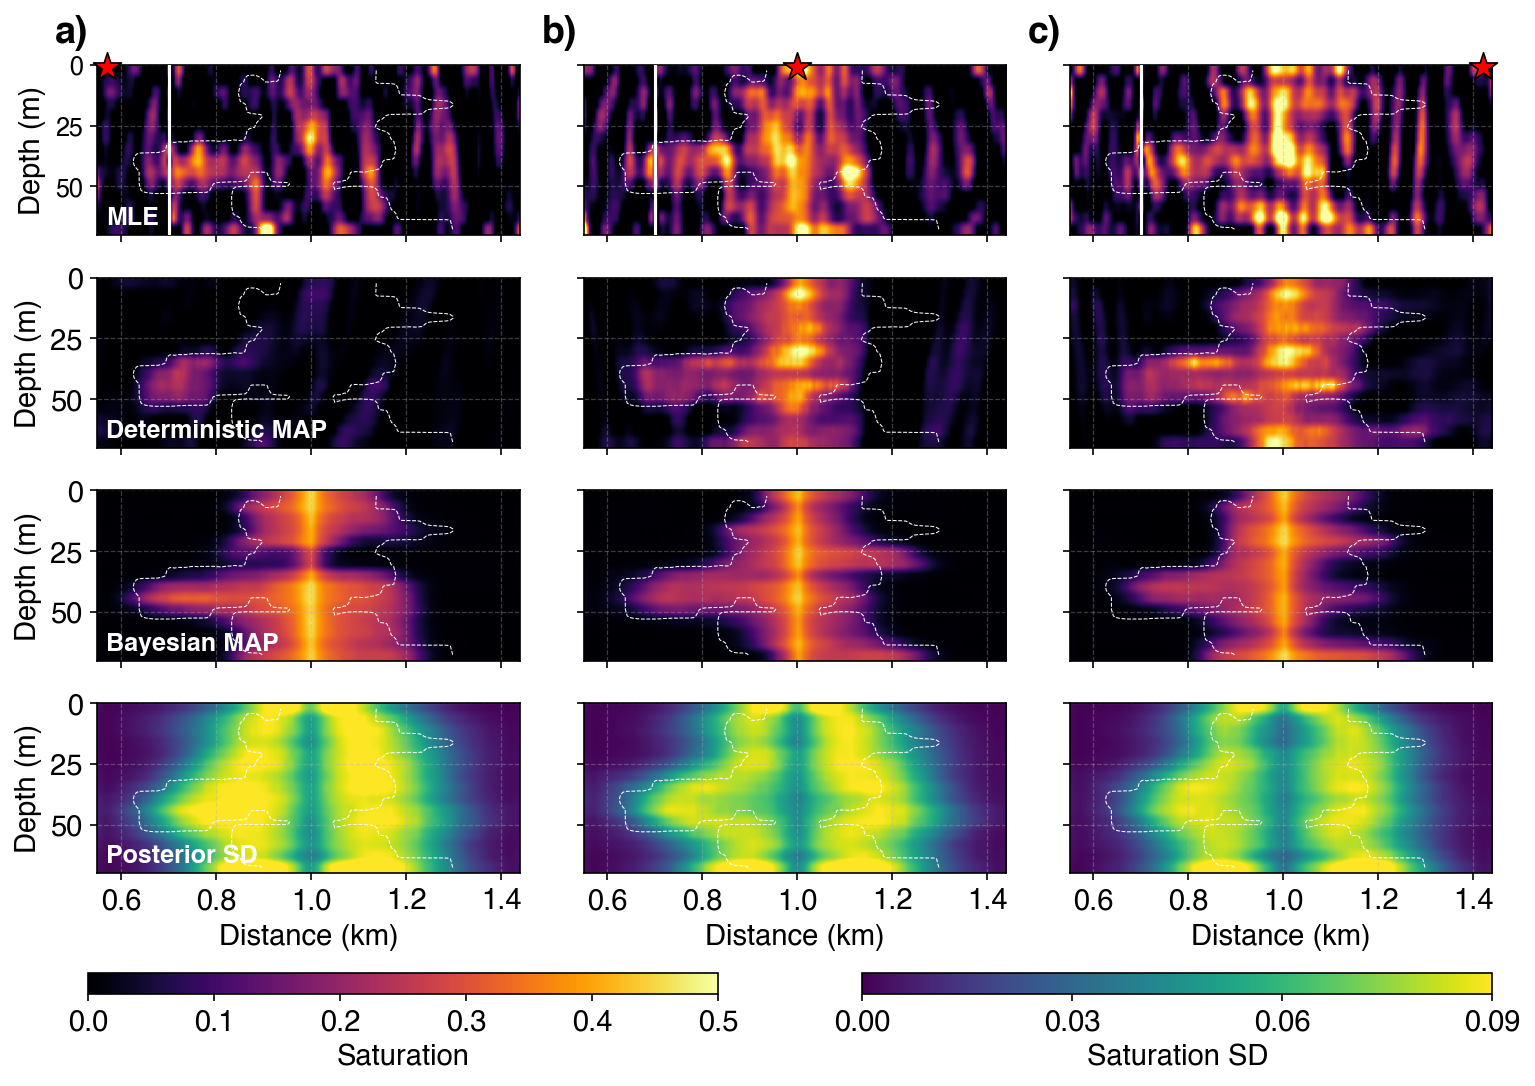

In [41]:
# ---- Setup figure ----
fig, axes = plt.subplots(4, 3, figsize=(12, 7), dpi=150, gridspec_kw={'wspace': 0.15, 'hspace': 0.25})
ims_col0, ims_col1, ims_col2, ims_col3 = [], [], [], []

for col, src_id_ in enumerate([2, 3, 4]):

    # MLE and Regularized MLE
    path = Path(f"/net/vision/scr2/haipeng/FWI-HMC-Revision/Runs-Paper/SYN-REG-Smooth-survey-{src_id_}-geophone-{rec_id}-{f0}Hz{noise_flag}")
    
    vp_fwi = AcousticModel.load(path/"Model-FWI.npz").get_model('vp') - vp_bl
    vp_fwi = vp_fwi[nz0:nz0+nz_res, nx0:nx0+nx_res]
    sa_fwi_inv = rockphysic_inversion(rockphy, vp_fwi, max_iter=100, verbose=False)

    vp_fwi_reg = AcousticModel.load(path/"Model-FWI-Smooth.npz").get_model('vp') - vp_bl
    vp_fwi_reg = vp_fwi_reg[nz0:nz0+nz_res, nx0:nx0+nx_res]
    sa_fwi_reg_inv = rockphysic_inversion(rockphy, vp_fwi_reg, max_iter=100, verbose=False)

    path = Path(f"/net/vision/scr2/haipeng/FWI-HMC/Runs-Paper/SYN-survey-{src_id_}-geophone-{rec_id}-{f0}Hz{noise_flag}")
    
    # Load data
    latent_posterior_az = az.from_netcdf(path / f"HMC/Posterior-hmc-num-{num_samples}-temp-{hmc_temp}.nc")
    latent_posterior    = latent_posterior_az.posterior['m'].values[0]
    latent_posterior_tensor = torch.as_tensor(latent_posterior, dtype=torch.float32, device=device)
    sa_post, sa_post_mean, sa_post_std, _,  _,  _ = decode_in_batches(model_vae, latent_posterior_tensor, 512)

    # Find MAP sample
    log_prob = np.load(path / f"HMC/LogProb-hmc-num-{num_samples}-temp-{hmc_temp}.npy")
    map_id = np.argmax(log_prob)
    sa_map = sa_post[map_id]

    # --- FWI
    ax0 = axes[0, col]
    im0 = ax0.imshow(sa_fwi_inv, cmap='inferno', vmin=0, vmax=0.5, aspect='auto', extent=extent_res)
    ax0.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')
    ax0.set_xticks(np.arange(0.60, 1.5, 0.2))
    ax0.grid(linestyle='--', alpha=0.35, linewidth=0.6)
    ims_col0.append(im0)

    # plot the source and receivers
    ax0.scatter(src_loc[src_id_] / 1000, 0.8, marker='*', s=200, color='red', edgecolor='k', linewidths=0.8, zorder=5, label="Source", clip_on=False)
    for rx in rec_loc[rec_id]:
        ax0.axvline(rx / 1000, linestyle='-', color='w', zorder=4, label="Geophone well" if rx == rec_loc[rec_id][0] else "")

    # --- FWI with regularization
    ax1 = axes[1, col]
    im1 = ax1.imshow(sa_fwi_reg_inv, cmap='inferno', vmin=0, vmax=0.5, aspect='auto', extent=extent_res)
    ax1.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')
    ax1.set_xticks(np.arange(0.60, 1.5, 0.2))
    ax1.set_yticks([0, 25, 50])
    ax1.grid(linestyle='--', alpha=0.35, linewidth=0.6)
    ax1.tick_params(axis='both', which='major', labelsize=fontsize)
    ims_col1.append(im1)

    # --- MAP
    ax2 = axes[2, col]
    im2 = ax2.imshow(sa_map, cmap='inferno', vmin=0, vmax=0.5, aspect='auto', extent=extent_res)
    ax2.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')
    ax2.set_xticks(np.arange(0.60, 1.5, 0.2))
    ax2.set_yticks([0, 25, 50])
    ax2.grid(linestyle='--', alpha=0.35, linewidth=0.6)
    ax2.tick_params(axis='both', which='major', labelsize=fontsize)
    ims_col2.append(im2)

    # --- Posterior std
    ax3 = axes[3, col]
    im3 = ax3.imshow(sa_post_std, cmap='viridis', vmin=0, vmax=0.09, aspect='auto', extent=extent_res)
    ax3.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')
    ax3.set_xticks(np.arange(0.60, 1.5, 0.2))
    ax3.set_yticks([0, 25, 50])
    ax3.grid(linestyle='--', alpha=0.35, linewidth=0.6)
    ax3.tick_params(axis='both', which='major', labelsize=fontsize)
    ims_col3.append(im3)

    ax0.text(-0.1, 1.19, labels[col], va='center', fontsize=fontsize+4, transform=ax0.transAxes, color='k', fontweight='bold')

    # Labels
    ax3.set_xlabel("Distance (km)", fontsize=fontsize)
    if col == 0:
        ax0.set_ylabel("Depth (m)", fontsize=fontsize)
        ax1.set_ylabel("Depth (m)", fontsize=fontsize)
        ax2.set_ylabel("Depth (m)", fontsize=fontsize)
        ax3.set_ylabel("Depth (m)", fontsize=fontsize)
    
    # close ticks for unnecessary plots
    if col != 0:
        ax0.set_yticklabels([])
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])
        ax3.set_yticklabels([])
        
    ax0.set_xticklabels([])
    ax1.set_xticklabels([])
    ax2.set_xticklabels([])

    # --- Axis labels
    if col == 0:
        for iii, label in enumerate(["MLE", "Deterministic MAP", "Bayesian MAP", "Posterior SD"]):
            axes[iii, 0].text(0.02, 0.1, label, va='center', fontsize=fontsize-2, transform=axes[iii, 0].transAxes, color='w', fontweight='bold')
            

# ---- Two equal colorbars at the bottom (outside loop) ----
cax_vel = fig.add_axes([0.12, -0.005, 0.35, 0.02])
cax_std = fig.add_axes([0.55, -0.005, 0.35, 0.02])

cbar_sat = fig.colorbar(ims_col0[0], cax=cax_vel, orientation='horizontal')
cbar_sat.ax.tick_params(labelsize=fontsize)
cbar_sat.set_label("Saturation", fontsize=fontsize)
    
cbar_std = fig.colorbar(ims_col3[0], cax=cax_std, orientation='horizontal')
cbar_std.ax.tick_params(labelsize=fontsize)
cbar_std.set_label("Saturation SD", fontsize=fontsize)
cbar_std.set_ticks([0, 0.03, 0.06, 0.09])

save_path = f"figures_revision/FWI-Regularization.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()